In [1]:
import pandas as pd
import random
import sys
#sys.path.insert(0, '/Users/eduardomorenoortiz/Desktop/ITAM/nanook/nlp_nanook/src') # Local
sys.path.insert(0, r'C:\Users\eduardo.moreno\OneDrive - NEORIS\Desktop\courses\nlp\nlp_nanook\src') # Windows
from utils.utils import clean_text, get_corpus_N_gram

# Exploratory Data Analysis (EDA)

## Read and preprocess data

In [2]:
data = pd.read_pickle(r'..\..\..\data\preprocessed\data_fb_pages_groups.pkl')

In [3]:
data.columns

Index(['Entity Name', 'Facebook Id', 'Likes at Posting', 'Post Created',
       'Type', 'Total Interactions', 'Likes', 'Comments', 'Shares', 'Love',
       'Wow', 'Haha', 'Sad', 'Angry', 'Care', 'Message', 'Image Text',
       'Link Text', 'Description', 'score', 'source'],
      dtype='object')

In [4]:
df_selected = data[['Facebook Id', 'Likes at Posting', 'Post Created', 'Type', 
                    'Total Interactions', 'Likes', 'Comments', 'Shares', 'Love', 'Wow', 'Haha', 'Sad', 'Angry', 'Care', 'Message', 'Image Text', 'Link Text', 'Description', 
                    'score']]

In [5]:
df_selected.head()

,Facebook Id,Likes at Posting,Post Created,Type,Total Interactions,Likes,Comments,Shares,Love,Wow,Haha,Sad,Angry,Care,Message,Image Text,Link Text,Description,score
0,153630631414604,NaN,2016-01-05 20:55:17 CST,Photo,"7,836",7266,442,63,51,1,9,2,0,2,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,36.28
1,344760762323803,NaN,2018-03-25 20:22:33 CST,Photo,"12,530",2946,44,9025,357,4,112,7,17,18,PORQUE VOTARE POR GUSTAVO PETRO Hoy quiero com...,NaN,NaN,NaN,338.65
2,663135523805166,NaN,2018-04-26 15:23:31 CDT,Photo,"3,727",2137,77,917,583,10,2,0,1,0,"Ministra de medio ambiente, a trabajar por el ...",NaN,NaN,NaN,29.12
3,461295120574213,NaN,2016-05-02 17:59:04 CDT,Photo,"3,146",2548,249,188,123,7,28,2,1,0,A LOS NACIDOS ENTRE 1970 Y 1987 Somos una gene...,NaN,NaN,NaN,22.31
4,663135523805166,NaN,2016-06-28 23:41:26 CDT,Photo,"2,804",2367,57,181,87,5,3,8,96,0,AYÚDANOS A COMPARTIR LA IMAGEN.. Por tan magni...,NaN,NaN,NaN,21.91


In [6]:
df_selected.shape

(1393585, 19)

Drop *nan* inside `Message` column

In [7]:
print(f"Cantidad de NAN: {sum([1 if pd.isna(x) else 0 for x in df_selected['Message']])}")
print(f"Cantidad de NAN (%): {round(sum([1 if pd.isna(x) else 0 for x in df_selected['Message']])/df_selected.shape[0]*100, 5)}%")
df_clean = df_selected.dropna(subset=['Message'])

Cantidad de NAN: 951
Cantidad de NAN (%): 0.06824%


In [8]:
df_clean = df_clean.reset_index()

Show some messages

In [9]:
random.seed(14112023)
for i in random.sample(range(0, df_clean.shape[0]), 10):
    print(df_clean['Message'][i])
    print('\n')

UNPSJB Día del Ingeniero Forestal El 16 de agosto se conmemora el "Día del Ingeniero Forestal" en la Argentina. La fecha fue elegida por el egreso del primer graduado en una Universidad del país, recibido en la Facultad de Santiago del Estero, en el año 1963. En la Sede Esquel de la Facultad de Ingeniería se ofrece esta carrera desde hace tres décadas. La fecha es propicia para reflexionar sobre la importancia de los bosques, su situación en el mundo y en particular en nuestra región, de la necesidad del mayor conocimiento y atención a este recurso y de su enorme utilidad y potencialidad para el desarrollo y bienestar de las comunidades que tienen la fortuna de poseerlos o las condiciones propicias para crearlos. Con las evidencias científicas del cambio climático que sufre nuestro planeta, manifestado por el calentamiento global por la acumulación de gases de efectos invernadero y consecuencia de las fuertes emisiones generadas por la actividad humana siendo el dióxido de carbonos - C

### Length of Messages

In [10]:
df_clean['messageChar_length'] = [x if pd.isna(x) else len(x) for x in df_clean['Message']]
df_clean['messageWords_length'] = [x if pd.isna(x) else len(x.split(' ')) for x in df_clean['Message']]

<Axes: ylabel='Frequency'>

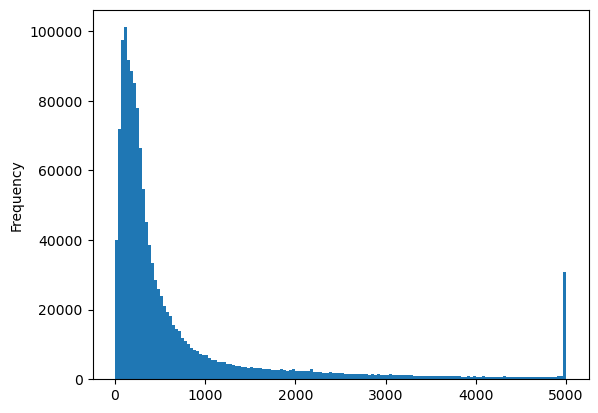

In [11]:
df_clean['messageChar_length'].plot(bins=150, kind='hist')

It is curious that there are "a lot" of messages with length aproximatly to $5,000$

In [12]:
df_clean['messageChar_length'].describe()

count    1.392634e+06
mean     7.012858e+02
std      1.060478e+03
min      1.000000e+00
25%      1.480000e+02
50%      2.880000e+02
75%      6.690000e+02
max      5.000000e+03
Name: messageChar_length, dtype: float64

In [13]:
df_clean[df_clean['messageChar_length'] == 5000]['Message'][166429]

'El Covid-19 y el retorno de la barbarie Por Víctor M. Toledo La barbarie en la historia humana es sinónimo de intolerancia y, en consecuencia, caldo fértil para el clasismo y racismo y para el advenimiento de sociedades totalitarias, pero también de gritos de rabia, radicalismo y desespera-ción que alimentan la sinrazón y niegan los aportes de la ciencia. En plena era digital, con 4 mil 540 millones de internautas, 60 por ciento de la población humana conectada a Internet, la crisis del mundo moderno parece inducir un nuevo florecimiento de la barbarie, del fanatismo de diversos colores, olores y sabores, ahora inducido, expandido y multiplicado por la red global y los medios de comunicación. Quienes pensaban que se habían superado los viejos tiempos oscuros y que la ciencia daría lugar a sociedades y ciudadanos orientados por el conocimiento objetivo y la razón, o por la pasión y la razón en conjunción equilibrada, hoy deben aceptar que padecían de un excesivo optimismo. Con un panor

In [14]:
for x in df_clean[df_clean['messageChar_length'] == 4999]['Message']:
    print(x[-20:])

 pobreza (truncated)
 ley del (truncated)
ecesario (truncated)
, y unos (truncated)
e estima (truncated)
llevaron (truncated)
otoBlog, (truncated)
ones del (truncated)
peratura (truncated)
ideraban (truncated)
fundas y (truncated)
Torrico. (truncated)
onsables (truncated)
a calle, (truncated)
cimiento (truncated)
bilidad. (truncated)
 en 2017 (truncated)
cimiento (truncated)
 países? (truncated)
océanos, (truncated)
torio de (truncated)
ntrol de (truncated)
ero sólo (truncated)
LA ÉPOCA (truncated)
 vida en (truncated)
urístico (truncated)
ero sólo (truncated)
 a la 5ª (truncated)
ienen al (truncated)
e, donde (truncated)
brientos (truncated)
stado de (truncated)
os donde (truncated)
ero sólo (truncated)
hasta tu (truncated)
opuestas (truncated)
minacion (truncated)
hat ¡POR (truncated)
 espacio (truncated)
zados el (truncated)
existía, (truncated)
 la isla (truncated)
na marcó (truncated)
 interés (truncated)
cidad de (truncated)
 NUESTRA (truncated)
entes se (truncated)
ectaría, (tru

Seems that facebook messages/publications are truncated to $4,999$ characters!

<Axes: ylabel='Frequency'>

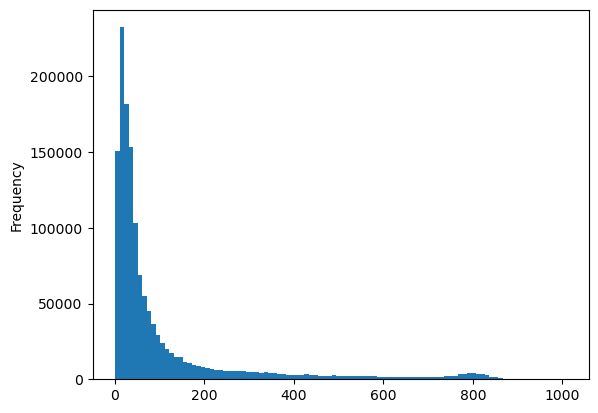

In [15]:
df_clean['messageWords_length'].plot(bins=100, kind='hist')

## N-grams

### Uni-gram

#### Raw

First, let's analyze text from **raw** (without any changes)

Length of corpus: 148948967


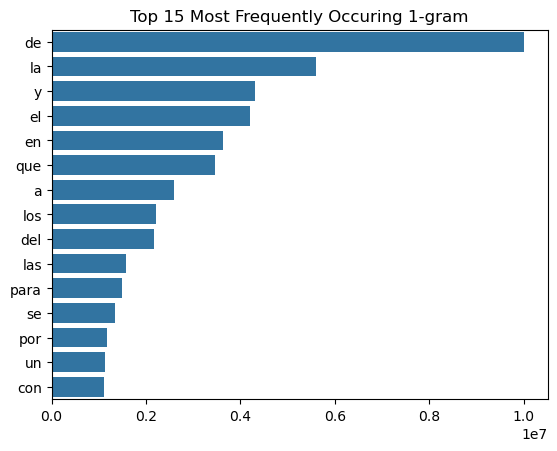

In [16]:
corpus = get_corpus_N_gram(list_text=df_clean['Message'], stop_words=None, ngram=1, show_plot=True)

Those are meaningless words, all of them (and similar) will be added to **stopwords**, so they won't be use for future analysis. 

#### With stop-words

In [17]:
with open(r'..\..\utils\spanish_stopwords.txt', 'r') as archivo:
    stop_words = [linea.strip() for linea in archivo]
len(stop_words)

608

In [18]:
stop_words[:10]

['a',
 'actualmente',
 'adelante',
 'además',
 'afirmó',
 'agregó',
 'ahora',
 'ahí',
 'al',
 'algo']

Length of corpus: 82266768


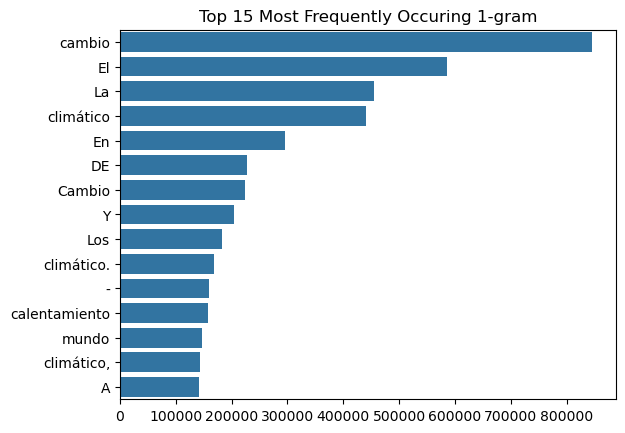

In [19]:
corpus = get_corpus_N_gram(list_text=df_clean['Message'], stop_words=stop_words, ngram=1, show_plot=True)

- Upper/Lower-case must be removed, so that "*Cambio*" and "*cambio*" are counted in the same word.
- It is suggested by the autor to remove accents
- No include punctiations signs: **, ; . : '**
- No include URLs inside text

#### Stop-words, text to lowercase, no URLs: clean text

In [20]:
df_clean['Message_clean'] = df_clean['Message'].apply(lambda x: clean_text(x))

Length of corpus: 76328334


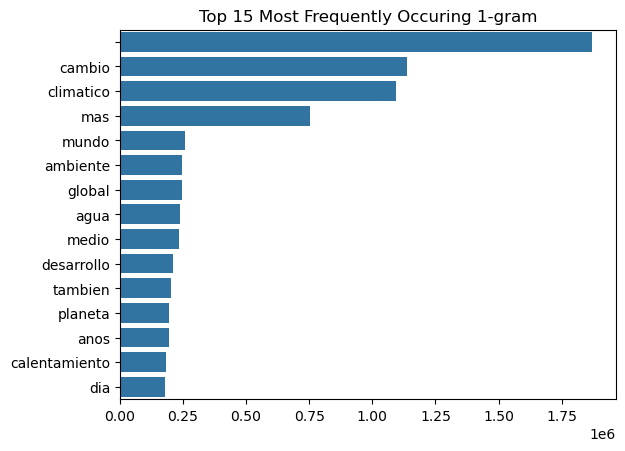

In [21]:
corpus = get_corpus_N_gram(list_text=df_clean['Message_clean'], stop_words=stop_words, ngram=1, show_plot=True)

### Bi-gram

Length of corpus: 74937107


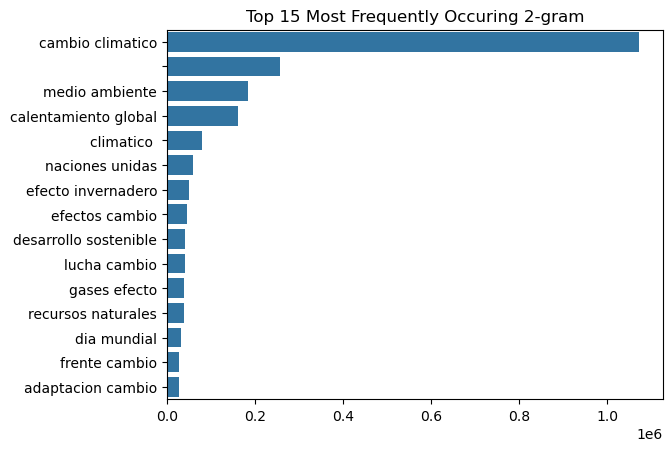

In [22]:
corpus = get_corpus_N_gram(list_text=df_clean['Message_clean'], stop_words=stop_words, ngram=2, show_plot=True)

### Tri-gram

Length of corpus: 73555955


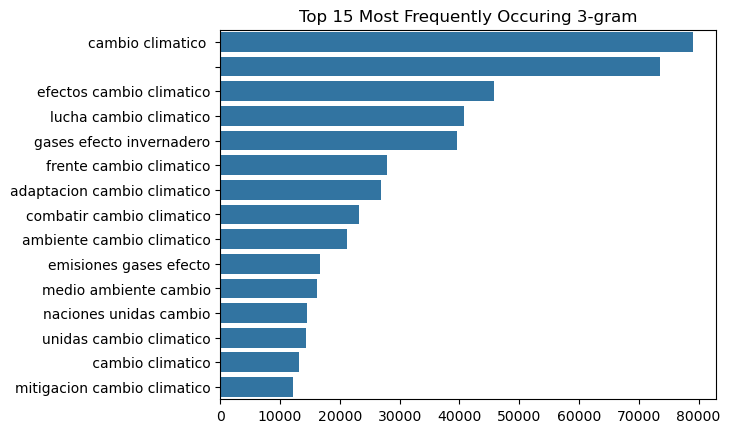

In [23]:
corpus = get_corpus_N_gram(df_clean['Message_clean'], stop_words=stop_words, ngram=3, show_plot=True)

In [24]:
df_clean.to_pickle(r'..\..\..\data\preprocessed\clean_text_nanook.pkl')